# Error models: there is a right way and many wrong ways

The same data, the same model, six covariances.  Which one you declare *is*
the statistical model, and the posteriors differ accordingly.  Along the way:
inferring a noise level the experiment did not report, a normalisation or
offset it did not report, sharing an error model between datasets, and
bringing your own covariance.

Recipes: 2, 4, 5, 19

In [1]:
import corner
import emcee
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

import rxmc as rx
from rxmc import terms as T

## Where a χ² comes from

Every fit assumes a likelihood, stated or not.  Counting events in a bin gives
a binomial, then a Poisson, then (many counts) a normal: with independent
bins that is a diagonal multivariate normal, and its log is `-χ²/2`.  Every
step is an assumption: independence between points, a model able to
reproduce the truth exactly, errors that are what the experiment says they
are.  When any of these fails the honest generalisation is to keep the
multivariate normal and *model its covariance*,

$$\log p(\mathbf{y}\mid\theta) = -\tfrac12 (\mathbf{y}-\mathbf{y}_m)^\mathsf{T}
\Sigma^{-1}(\mathbf{y}-\mathbf{y}_m) - \tfrac12\log\det\Sigma + \text{const},$$

so that Σ carries the statistical errors, the correlated systematics and the
things you had to infer.  In `rxmc` a covariance is a sum of `terms`; the
rest of this notebook is a tour of what the choice of terms does.

## Data with a defect the experiment did not report

A line, 5 % relative noise, and one overall normalisation drawn 10 % low.
The experiment reports the noise correctly but says nothing about the
normalisation.

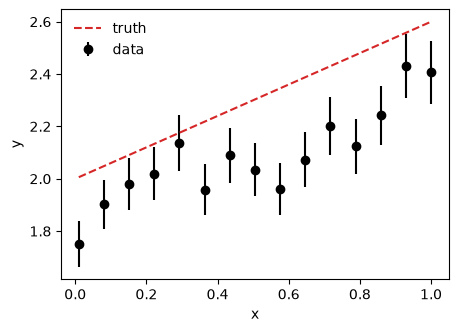

In [2]:
rng = np.random.default_rng(16)
truth = {"m": 0.6, "b": 2.0}
x = np.linspace(0.01, 1.0, 15)
y_true = truth["m"] * x + truth["b"]
noise_fraction, sys_fraction = 0.05, 0.10
scale = 1.0 - sys_fraction  # the realised normalisation, one sigma low
y_meas = (y_true + rng.normal(0.0, noise_fraction * y_true)) * scale
data = rx.Dataset(x, y_meas, noise_fraction * y_meas, label="biased")

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.errorbar(data.x, data.y, data.y_err, fmt="o", color="k", label="data")
ax.plot(x, y_true, "--", color="C3", label="truth")
ax.set(xlabel="x", ylabel="y")
ax.legend(frameon=False)
plt.show()

## The model, a prior, and a way to run the ladder

The prior is deliberately far from the truth so that the data, not the
prior, decide.  `fit` runs emcee on any problem; `band` pushes posterior
rows through the model on a fine grid.  Both read columns by name.

In [3]:
m = rx.Parameter("m", prior=stats.norm(2.0, 2.0), latex="m")
b = rx.Parameter("b", prior=stats.norm(5.0, 2.0), latex="b")
line = rx.Model(lambda x, m, b: m * x + b, [m, b])
x_fine = np.linspace(0.0, 1.0, 40)


def fit(problem, seed, n_walkers=24, n_steps=1800):
    sampler = emcee.EnsembleSampler(n_walkers, problem.ndim, problem.log_posterior)
    sampler.random_state = np.random.RandomState(seed).get_state()
    sampler.run_mcmc(problem.sample_prior(n_walkers, rng=seed), n_steps, progress=False)
    return sampler.get_chain(discard=n_steps // 3, thin=5, flat=True)


def band(problem, samples, levels=(5, 95)):
    on_fine = line.bind(x_fine, {})
    cols = problem.columns(line.params)
    return rx.predictive.predictive_band(
        [on_fine(*s[cols]) for s in samples[::10]], levels=levels
    )


def summary(problem, samples):
    return "  ".join(
        f"{n} = {samples[:, i].mean():.3f} +/- {samples[:, i].std():.3f}"
        for i, n in enumerate(problem.names)
    )


comp = rx.Comparison(data, line)

## 1. Reported statistics only

The default: the covariance is the diagonal of `y_err`.  Nothing knows about
the normalisation, so the posterior is precise and wrong.

In [4]:
p_stat = rx.Problem([rx.Constraint([comp])])
s_stat = fit(p_stat, seed=1)
print(summary(p_stat, s_stat))

m = 0.483 +/- 0.087  b = 1.836 +/- 0.049


## 2. Infer the noise level (recipe 2)

Suppose the experiment had not reported errors at all.  `T.noise_fraction`
puts a free relative noise `σ_i = ε · ym_i` on the diagonal, sampled in log
space; `statistical=False` drops the reported diagonal so the inferred one
replaces it.  `T.noise` is the constant-floor variant, `σ_i = ε`.  Both
terms are *additive*: without `statistical=False` they would inflate the
reported errors instead of replacing them.

In [5]:
log_eps = rx.Parameter(
    "log_eps", prior=stats.norm(np.log(0.05), 1.0), latex=r"\log\epsilon"
)
p_noise = rx.Problem(
    [rx.Constraint([comp], terms=[T.noise_fraction(log_eps)], statistical=False)]
)
s_noise = fit(p_noise, seed=2)
print(p_noise.names)
print(summary(p_noise, s_noise))
print(
    f"inferred noise fraction: {np.exp(s_noise[:, 2]).mean():.3f}   (generated with {noise_fraction})"
)

['m', 'b', 'log_eps']
m = 0.531 +/- 0.277  b = 1.909 +/- 0.404  log_eps = -2.981 +/- 0.425
inferred noise fraction: 0.061   (generated with 0.05)


## 3. The reported systematic, as a correlated mode

If the experiment *had* reported a 10 % normalisation uncertainty, the honest
covariance adds a rank-one mode proportional to the prediction:
`Σ_ij = δ_ij σ_i² + (0.1)² ym_i ym_j`.  Because the mode reads `ym`, the
covariance changes with the parameters; `rxmc` assembles it at every
likelihood call.

In [6]:
p_norm = rx.Problem(
    [rx.Constraint([comp], terms=[T.normalization(magnitude=sys_fraction)])]
)
s_norm = fit(p_norm, seed=3)
print(summary(p_norm, s_norm))

m = 0.503 +/- 0.104  b = 1.917 +/- 0.220


## 4. The same mode built from the data: Peelle's Pertinent Puzzle

The tempting shortcut is to build the mode from the measured values,
`(0.1)² y_i y_j`, as a fixed matrix.  `rxmc` accepts any symmetric block as a
term (recipe 19), so the mistake is easy to spell.  It is the covariance of
Peelle's Pertinent Puzzle: the fit is pulled *below* the data (recipes 27
and 37 have the closed forms).

In [7]:
wrong = rx.Term(sys_fraction**2 * np.outer(data.y, data.y), kind="matrix")
p_wrong = rx.Problem([rx.Constraint([comp], terms=[wrong])])
s_wrong = fit(p_wrong, seed=4)
print(summary(p_wrong, s_wrong))

m = 0.439 +/- 0.097  b = 1.680 +/- 0.184


### Four posteriors, one truth

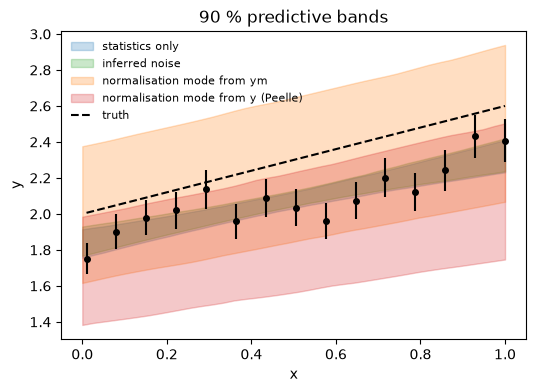

In [8]:
runs = {
    "statistics only": (p_stat, s_stat, "C0"),
    "inferred noise": (p_noise, s_noise, "C2"),
    "normalisation mode from ym": (p_norm, s_norm, "C1"),
    "normalisation mode from y (Peelle)": (p_wrong, s_wrong, "C3"),
}
fig, ax = plt.subplots(figsize=(6, 4))
for label, (p, s, color) in runs.items():
    lo, hi = band(p, s)
    ax.fill_between(x_fine, lo, hi, color=color, alpha=0.25, label=label)
ax.plot(x, y_true, "--", color="k", label="truth")
ax.errorbar(data.x, data.y, data.y_err, fmt="o", color="k", ms=4)
ax.set(xlabel="x", ylabel="y", title="90 % predictive bands")
ax.legend(frameon=False, fontsize=8)
plt.show()

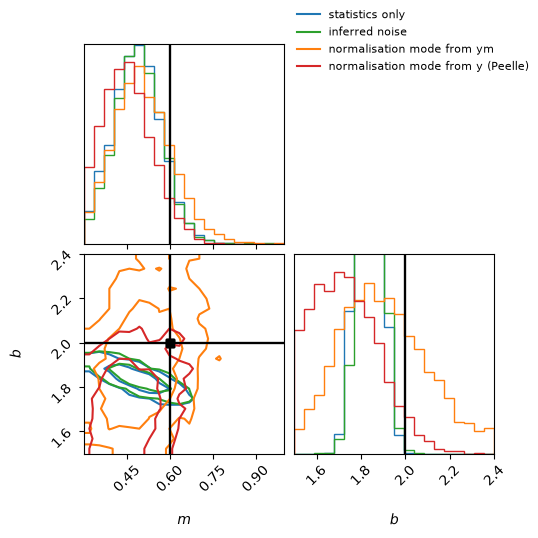

In [9]:
fig = None
for label, (p, s, color) in runs.items():
    fig = corner.corner(
        s[:, p.columns(line.params)],
        fig=fig,
        color=color,
        labels=["$m$", "$b$"],
        truths=[truth["m"], truth["b"]],
        truth_color="k",
        plot_datapoints=False,
        plot_density=False,
        levels=(0.68, 0.95),
        range=[(0.3, 1.0), (1.5, 2.4)],
    )
fig.legend(
    handles=[plt.Line2D([], [], color=c, label=l) for l, (_, _, c) in runs.items()],
    loc="upper right",
    frameon=False,
    fontsize=8,
)
plt.show()

Only the mode built from the prediction covers the truth with an honest
width.  Statistics only is precise and biased; the inferred noise recovers
the 5 % the experiment reported and is therefore just as precise and just
as biased, because a diagonal cannot describe a common shift; the Peelle
covariance is biased further down and narrower than the honest one.

## 5. Infer a normalisation or an offset the experiment did not report (recipe 4)

The mode's magnitude need not be known.  `T.normalization(log_eta)` samples
it; `T.offset(...)` is the same for an additive shift.  Here is an offset
defect, treated with the magnitude known and with it free.

In [10]:
offset = 0.3
y_off = y_true + rng.normal(0.0, noise_fraction * y_true) + offset
data_off = rx.Dataset(x, y_off, noise_fraction * y_off, label="offset")
comp_off = rx.Comparison(data_off, line)

log_omega = rx.Parameter(
    "log_omega", prior=stats.norm(np.log(0.3), 1.0), latex=r"\log\omega"
)
p_off_known = rx.Problem(
    [rx.Constraint([comp_off], terms=[T.offset(magnitude=offset)])]
)
p_off_free = rx.Problem([rx.Constraint([comp_off], terms=[T.offset(log_omega)])])
p_off_ignored = rx.Problem([rx.Constraint([comp_off])])
for name, p in [
    ("known", p_off_known),
    ("free", p_off_free),
    ("ignored", p_off_ignored),
]:
    s = fit(p, seed=5)
    print(f"offset {name:8s}: {summary(p, s)}")

offset known   : m = 0.535 +/- 0.109  b = 2.359 +/- 0.310


offset free    : m = 0.547 +/- 0.108  b = 2.553 +/- 0.725  log_omega = -1.140 +/- 1.013


offset ignored : m = 0.535 +/- 0.110  b = 2.301 +/- 0.061


## Sharing an error model between datasets (recipe 5)

A second experiment measures the same line with its own normalisation
defect.  Two ways to couple them:

- **case B**, share the *parameter*: pass the same `log_eps` object to a
  term on each comparison.  One column, two block-diagonal blocks.
- **case A**, share the *mode*: one normalisation term `on=[comp1, comp2]`
  couples the data through off-diagonal blocks (the next notebook).

Here is case B with the noise fraction inferred once for both.

In [11]:
x2 = np.linspace(0.01, 0.8, 27)
y2_true = truth["m"] * x2 + truth["b"]
y2 = (y2_true + rng.normal(0.0, 0.025 * y2_true)) * 1.1  # 10 % high
data2 = rx.Dataset(x2, y2, 0.025 * y2, label="second")
comp2 = rx.Comparison(data2, line)

shared = rx.Parameter("log_eps", prior=stats.norm(np.log(0.05), 1.0))
c_shared = rx.Constraint(
    [comp, comp2],
    terms=[T.noise_fraction(shared, on=comp), T.noise_fraction(shared, on=comp2)],
    statistical=False,
)
p_shared = rx.Problem([c_shared])
print("one shared object -> one column:", p_shared.names)

eps1 = rx.Parameter("log_eps_1", prior=stats.norm(np.log(0.05), 1.0))
eps2 = rx.Parameter("log_eps_2", prior=stats.norm(np.log(0.05), 1.0))
c_separate = rx.Constraint(
    [comp, comp2],
    terms=[T.noise_fraction(eps1, on=comp), T.noise_fraction(eps2, on=comp2)],
    statistical=False,
)
print("two objects -> two columns:  ", rx.Problem([c_separate]).names)
s_shared = fit(p_shared, seed=6)
print(summary(p_shared, s_shared))

one shared object -> one column: ['m', 'b', 'log_eps']
two objects -> two columns:   ['m', 'b', 'log_eps_1', 'log_eps_2']


m = 0.428 +/- 0.140  b = 2.155 +/- 0.068  log_eps = -2.326 +/- 0.111


The two datasets disagree by 20 %, and a diagonal noise is the only
freedom this error model has: the inferred noise grows to about 10 % to
absorb the disagreement, the slope is covered, the intercept only just.
A normalisation mode per dataset is the model that knows what happened.

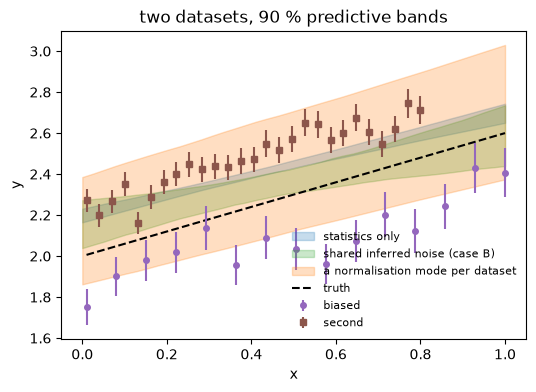

In [12]:
p_both_stat = rx.Problem([rx.Constraint([comp, comp2])])
s_both_stat = fit(p_both_stat, seed=7)
p_both_norm = rx.Problem(
    [
        rx.Constraint(
            [comp, comp2],
            terms=[
                T.normalization(magnitude=0.1, on=comp),
                T.normalization(magnitude=0.1, on=comp2),
            ],
        )
    ]
)
s_both_norm = fit(p_both_norm, seed=8)

fig, ax = plt.subplots(figsize=(6, 4))
for label, (p, s, color) in {
    "statistics only": (p_both_stat, s_both_stat, "C0"),
    "shared inferred noise (case B)": (p_shared, s_shared, "C2"),
    "a normalisation mode per dataset": (p_both_norm, s_both_norm, "C1"),
}.items():
    lo, hi = band(p, s)
    ax.fill_between(x_fine, lo, hi, color=color, alpha=0.25, label=label)
ax.plot(x, y_true, "--", color="k", label="truth")
ax.errorbar(data.x, data.y, data.y_err, fmt="o", color="C4", ms=4, label=data.label)
ax.errorbar(data2.x, data2.y, data2.y_err, fmt="s", color="C5", ms=4, label=data2.label)
ax.set(xlabel="x", ylabel="y", title="two datasets, 90 % predictive bands")
ax.legend(frameon=False, fontsize=8)
plt.show()

## Takeaways

- The covariance is the statistical model.  Declaring it is the work; the
  inference machinery does not change from one row of the ladder to the next.
- A defect the experiment did not report can be inferred: a noise level, a
  normalisation, an offset, each one column in the chain.
- A correlated systematic is a mode built from the *prediction*.  Built from
  the data it is Peelle's Pertinent Puzzle.
- Sharing a `Parameter` object couples parameters (case B); a term spanning
  comparisons couples data (case A).  Both are declared, never configured.